In [2]:
import requests
import json
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

Convert the rerutned data from dict to dataframe

In [3]:
url = "https://api.glasgow.gov.uk/traffic/v1/movement/sites"
response = requests.get(url)

In [4]:
if response.status_code == 200:
    data = response.json()
else:
    raise Exception(f"reque fail: {response.status_code}")

In [5]:
print(data)

[{'siteId': 'GH020A_B', 'from': {'description': 'Gallowgate west to Sword St', 'lat': '55.8543754827825', 'long': '-4.217259197086495'}, 'to': {'description': 'Gallowgate west to Sword St', 'lat': '55.854434529999814', 'long': '-4.216974959509279'}}, {'siteId': 'GJ3301_D', 'from': {'description': 'Carmunnock Rd southbound', 'lat': '55.821736212748405', 'long': '-4.2561270616272875'}, 'to': {'description': 'Carmunnock Rd southbound', 'lat': '55.82105417976632', 'long': '-4.25607160697339'}}, {'siteId': 'GH020A_A', 'from': {'description': 'Gallowgate east to Sword St', 'lat': '55.85539015389372', 'long': '-4.225769520669405'}, 'to': {'description': 'Gallowgate east to Sword St', 'lat': '55.85526881737797', 'long': '-4.2260182328994995'}}, {'siteId': 'GJ3301_C', 'from': {'description': 'Carmunnock Rd northbound to Kings Park Avenue', 'lat': '55.81925458152306', 'long': '-4.255696036412074'}, 'to': {'description': 'Carmunnock Rd northbound to Kings Park Avenue', 'lat': '55.81849086854625',

In [6]:
def dict_to_dataframe(data):
    data_dict = {}
    for feature in data[0]:
        data_dict[feature] = [each_record[feature] for each_record in data]
    data_df = pd.DataFrame.from_dict(data_dict)
    
    return data_df

In [7]:
sites = data

In [8]:
print(sites)

[{'siteId': 'GH020A_B', 'from': {'description': 'Gallowgate west to Sword St', 'lat': '55.8543754827825', 'long': '-4.217259197086495'}, 'to': {'description': 'Gallowgate west to Sword St', 'lat': '55.854434529999814', 'long': '-4.216974959509279'}}, {'siteId': 'GJ3301_D', 'from': {'description': 'Carmunnock Rd southbound', 'lat': '55.821736212748405', 'long': '-4.2561270616272875'}, 'to': {'description': 'Carmunnock Rd southbound', 'lat': '55.82105417976632', 'long': '-4.25607160697339'}}, {'siteId': 'GH020A_A', 'from': {'description': 'Gallowgate east to Sword St', 'lat': '55.85539015389372', 'long': '-4.225769520669405'}, 'to': {'description': 'Gallowgate east to Sword St', 'lat': '55.85526881737797', 'long': '-4.2260182328994995'}}, {'siteId': 'GJ3301_C', 'from': {'description': 'Carmunnock Rd northbound to Kings Park Avenue', 'lat': '55.81925458152306', 'long': '-4.255696036412074'}, 'to': {'description': 'Carmunnock Rd northbound to Kings Park Avenue', 'lat': '55.81849086854625',

In [9]:
sensors_df = dict_to_dataframe(sites)

In [10]:
sensors_df['longitude'] = sensors_df['from'].apply(lambda x: float(x['long']))
sensors_df['latitude'] = sensors_df['from'].apply(lambda x: float(x['lat']))
sensors_df['label'] = sensors_df['from'].apply(lambda x: x['description'])

In [11]:
sensors_df = sensors_df[['siteId','label','longitude','latitude']]

In [12]:
sensors_df = sensors_df.sort_values(by='siteId').reset_index(drop=True)

In [13]:
sensors_df

,siteId,label,longitude,latitude
0,DD1701_A,Glasgow Road southbound to Mill Road,-4.389503,55.892071
1,DD1701_B,Glasgow Road outbound to Mill Road,-4.383175,55.890091
2,DD1701_C,Mill Road,-4.386650,55.891983
3,GA0100_S,Broomielaw / Brown Street (gen traffic E/B),-4.265401,55.856842
4,GA0101_D,Anderston Quay - Fastlink Crossover westbound,-4.273542,55.856709
...,...,...,...,...
1270,GL4101_B,Moss Road e/b,-4.334829,55.864540
1271,GL4101_T,NSGH Boulevard,-4.337842,55.864941
1272,GL4151_B,Renfrew Road e/b,-4.339914,55.865908
1273,GL4151_C,Renfrew Road n/b,-4.339927,55.865333


Create a geodataframe

Set coordinate reference system

Reprojecting

Fliter the sensors via locations

Create static and interactive map 

In [14]:
# Create a GeoDataFrame
sensors_df["geometry"] = gpd.points_from_xy(sensors_df["longitude"], sensors_df["latitude"])
# Set coordinate reference system
sensors_gdf = gpd.GeoDataFrame(sensors_df, crs="epsg:4326")
# Reproject
sensors_gdf = sensors_gdf.to_crs("epsg:3857")
sensors_gdf

,siteId,label,longitude,latitude,geometry
0,DD1701_A,Glasgow Road southbound to Mill Road,-4.389503,55.892071,POINT (-488637.187 7536960.045)
1,DD1701_B,Glasgow Road outbound to Mill Road,-4.383175,55.890091,POINT (-487932.852 7536566.902)
2,DD1701_C,Mill Road,-4.386650,55.891983,POINT (-488319.662 7536942.485)
3,GA0100_S,Broomielaw / Brown Street (gen traffic E/B),-4.265401,55.856842,POINT (-474822.213 7529969.505)
4,GA0101_D,Anderston Quay - Fastlink Crossover westbound,-4.273542,55.856709,POINT (-475728.532 7529943.279)
...,...,...,...,...,...
1270,GL4101_B,Moss Road e/b,-4.334829,55.864540,POINT (-482550.922 7531496.545)
1271,GL4101_T,NSGH Boulevard,-4.337842,55.864941,POINT (-482886.31 7531576.125)
1272,GL4151_B,Renfrew Road e/b,-4.339914,55.865908,POINT (-483116.964 7531768.004)
1273,GL4151_C,Renfrew Road n/b,-4.339927,55.865333,POINT (-483118.448 7531653.843)


In [15]:
borough_uk = gpd.read_file('C:/Users/bnj/PTUA/PTUA2026/Lab06/data/district_borough_unitary.shp')
borough_gla = borough_uk.loc[borough_uk['Name']=='Glasgow City'].to_crs("epsg:3857")

sensors_join = gpd.sjoin(sensors_gdf, borough_gla, how ='inner', predicate ='within')

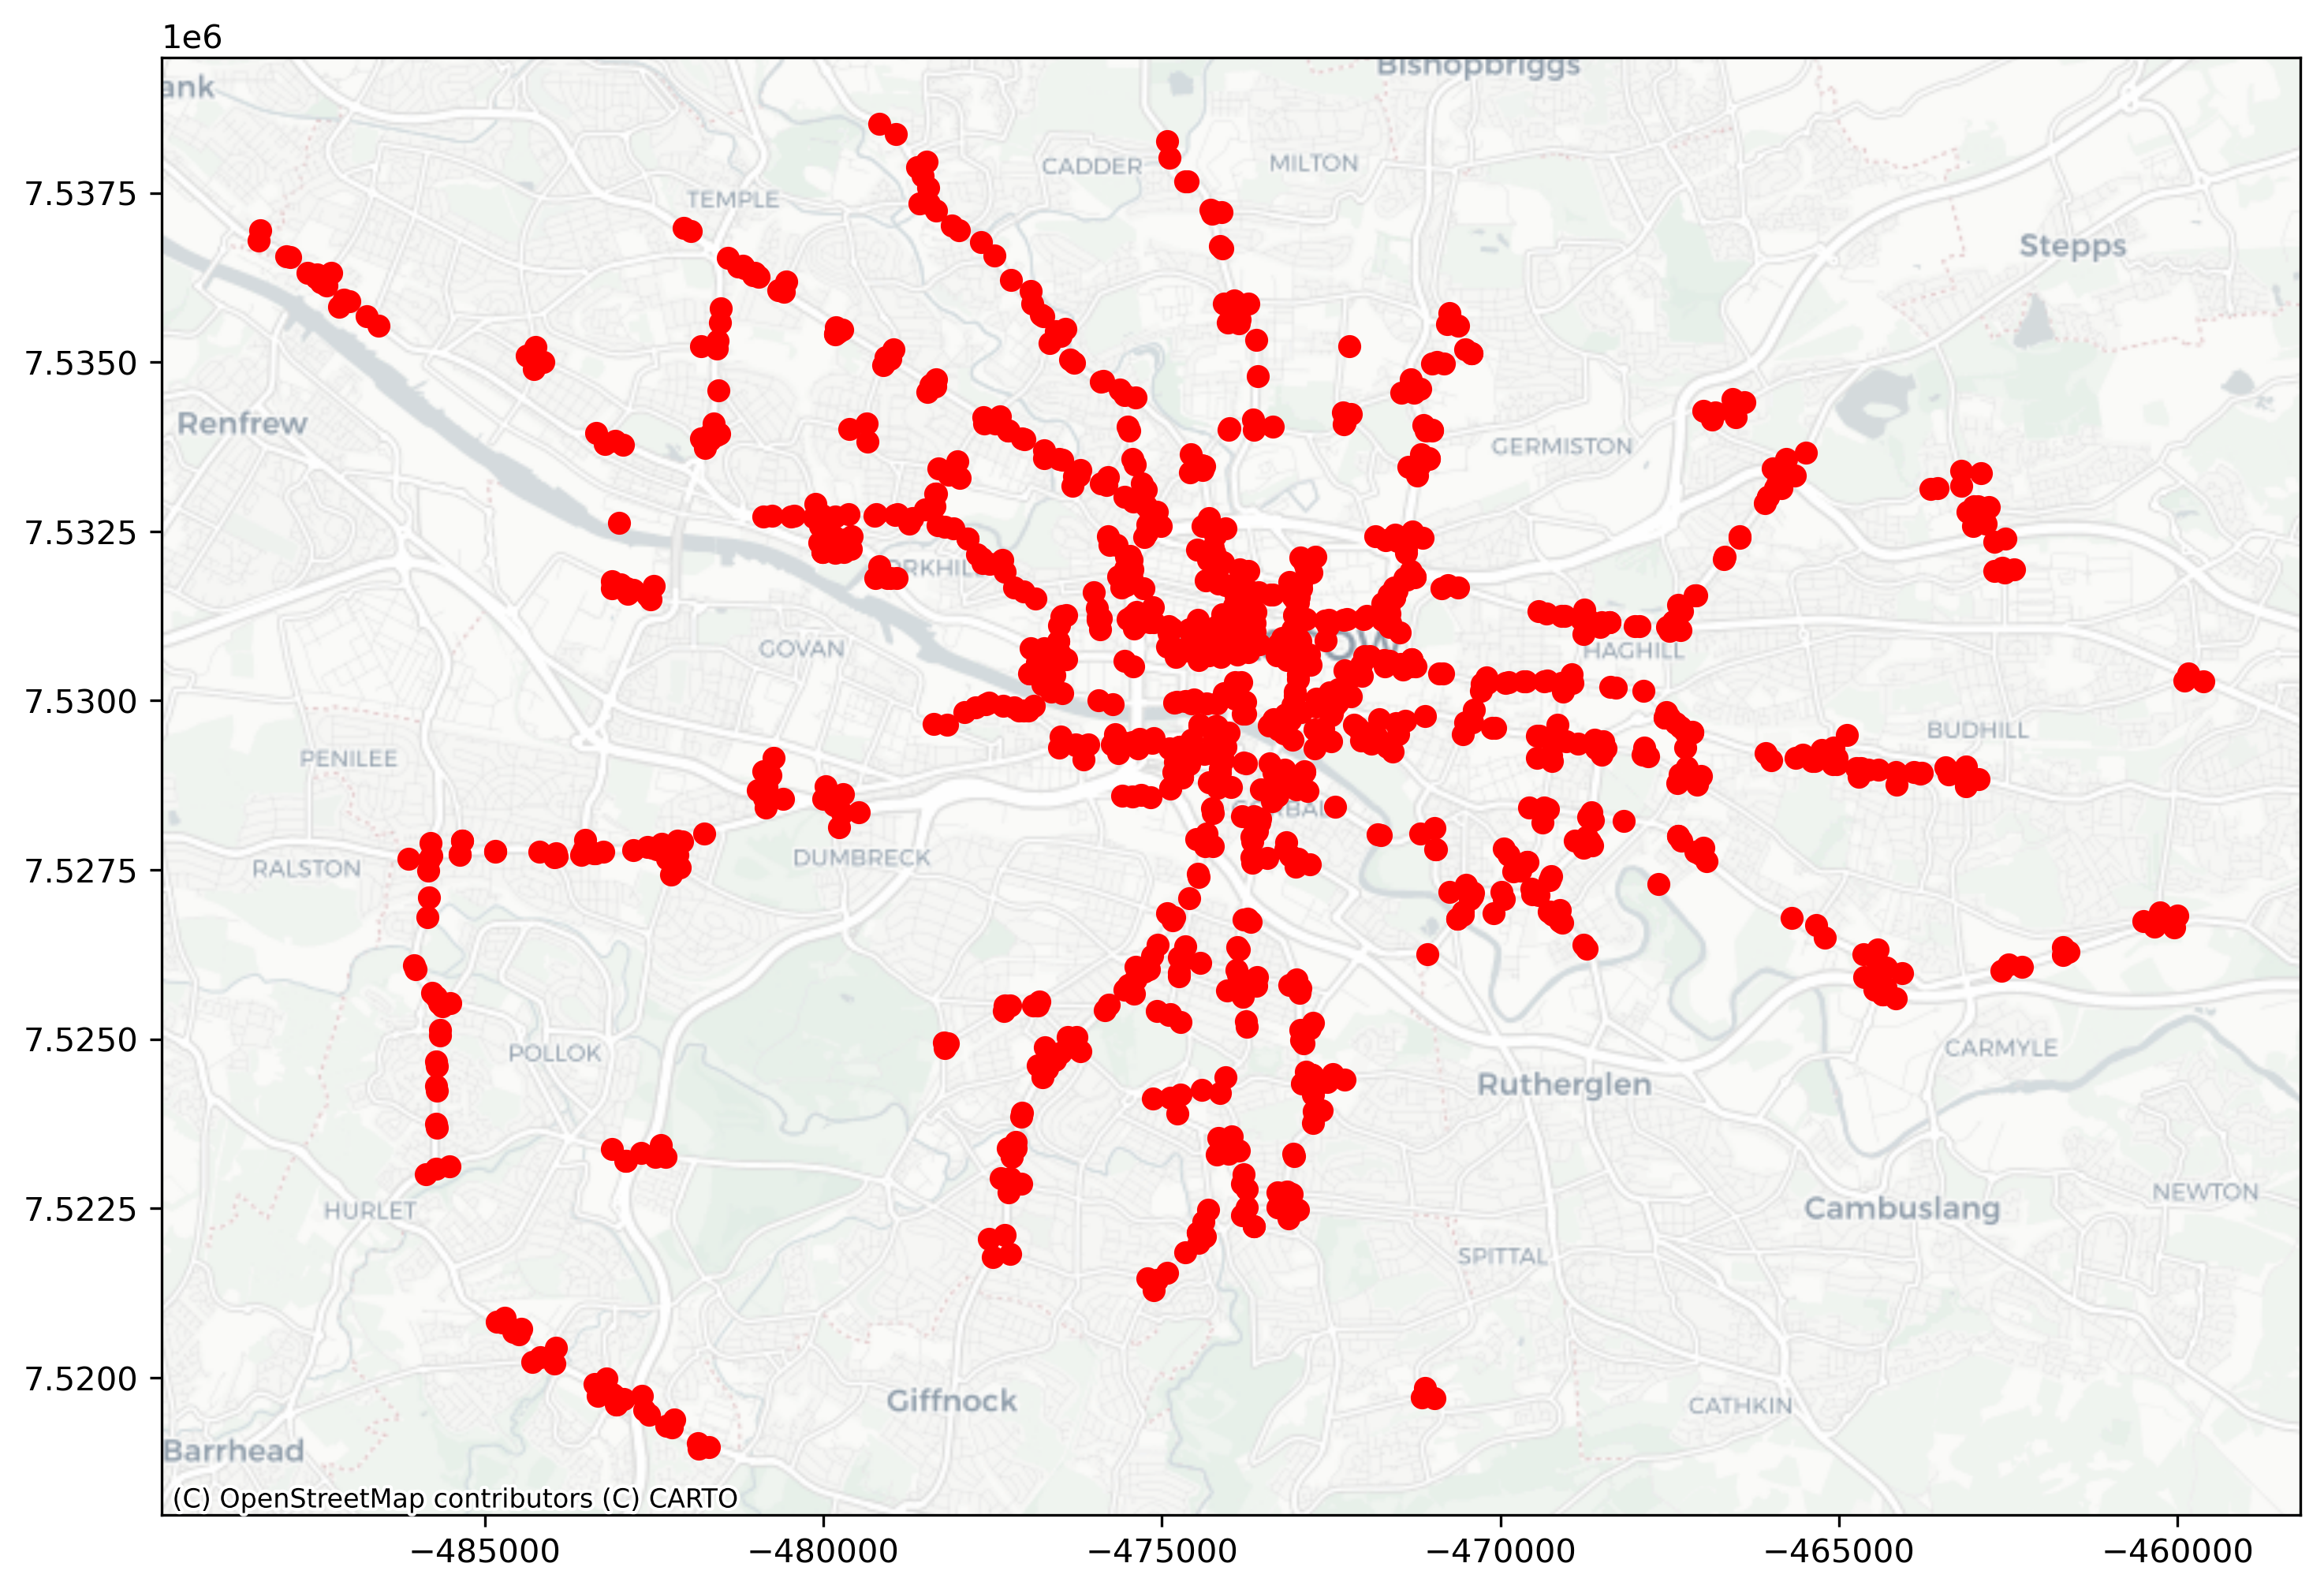

In [16]:
fig, ax = plt.subplots(figsize=(12,8), dpi=300) 
#Plot the data
sensors_join.plot(color = 'red',ax=ax)
#Add basemap
ctx.add_basemap(ax, crs="EPSG:3857", source=ctx.providers.CartoDB.Positron)

In [17]:
sensors_join.explore(color="Red",tiles='cartodbpositron', tooltip=['siteId','label','latitude','longitude'], 
                    width=750, height=500)